In [1]:
import time 
from functools import reduce
from collections import Counter
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.ldamulticore import LdaMulticore
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus

import pyLDAvis
import pyLDAvis.gensim_models

In [2]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [3]:
# 圖形設定中文
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = './SourceHanSansTW-Regular.otf'  # Your font path goes here
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus']=False #使負號能夠顯示
plt.rcParams['font.sans-serif'] = prop.get_name()

## 資料前處理

In [4]:
udn = pd.read_csv("raw_data/data_merged.csv")  # 匯資料
udn.head(3)

,Unnamed: 0,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,0,113,https://www.ptt.cc/bbs/Tech_Job/M.1675310634.A...,[討論]工研院資通所,2023-02-02 12:03:52,Rimowa,Tech_Job,轉貼\n\n醋院的薪水分享 (Dcard)\nhttps://www.dcard.tw/f/...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""getbacker"", ...",180.217.248.23,2023-02-03 01:45:14,ptt
1,1,483,https://www.ptt.cc/bbs/Tech_Job/M.1683208121.A...,[討論]該選擇設備還是機構？！,2023-05-04 21:48:39,sasaya7749,Tech_Job,嗨囉\n\n我就機械仔\n\n雖然修完iclab\n\n但出社會後依然面對現實\n\n最近拿...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""jim543000"", ...",101.9.100.191,2023-05-05 02:14:48,ptt
2,2,90,https://www.ptt.cc/bbs/Tech_Job/M.1674480733.A...,[問卷]員工敏捷關鍵事例研究問卷,2023-01-23 21:32:11,Obecne,Tech_Job,各位新年好，\n這裡是國立政治大學心理學研究所系工商心理學組的碩士班研究生，\n目前正在進行...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""hb177"", ""cmt...",114.43.90.80,2023-01-24 01:42:08,ptt


In [5]:
columns_to_drop = ['Unnamed: 0', 'artPoster', 'artComment', 'e_ip', 'insertedDate']
udn = udn.drop(columns=columns_to_drop)
udn.head(3)

,system_id,artUrl,artTitle,artDate,artCatagory,artContent,dataSource
0,113,https://www.ptt.cc/bbs/Tech_Job/M.1675310634.A...,[討論]工研院資通所,2023-02-02 12:03:52,Tech_Job,轉貼\n\n醋院的薪水分享 (Dcard)\nhttps://www.dcard.tw/f/...,ptt
1,483,https://www.ptt.cc/bbs/Tech_Job/M.1683208121.A...,[討論]該選擇設備還是機構？！,2023-05-04 21:48:39,Tech_Job,嗨囉\n\n我就機械仔\n\n雖然修完iclab\n\n但出社會後依然面對現實\n\n最近拿...,ptt
2,90,https://www.ptt.cc/bbs/Tech_Job/M.1674480733.A...,[問卷]員工敏捷關鍵事例研究問卷,2023-01-23 21:32:11,Tech_Job,各位新年好，\n這裡是國立政治大學心理學研究所系工商心理學組的碩士班研究生，\n目前正在進行...,ptt


In [6]:
# 移除網址格式
# 只留下中文字
udn["artContent"] = udn["artContent"].str.replace("(http|https)://.*", "", regex=True)
udn["artTitle"] = udn["artTitle"].str.replace("(http|https)://.*", "", regex=True)
udn["artContent"] = udn["artContent"].str.replace("[^\u4e00-\u9fa5]+", "", regex=True)
udn["artTitle"] = udn["artTitle"].str.replace("[^\u4e00-\u9fa5]+", "", regex=True)
udn['content'] = udn['artContent']


udn = udn.loc[:,["content", "artUrl", "artCatagory", 'artDate']]  # 文章內容 文章連結
udn.head(3)

,content,artUrl,artCatagory,artDate
0,轉貼醋院的薪水分享節錄部分科技業爆發前進去醋院第一年未滿一年本薪餐補年中年終調薪考績第二年滿...,https://www.ptt.cc/bbs/Tech_Job/M.1675310634.A...,Tech_Job,2023-02-02 12:03:52
1,嗨囉我就機械仔雖然修完但出社會後依然面對現實最近拿到的都是半導體方面的設備機構該選哪個勒還是轉生,https://www.ptt.cc/bbs/Tech_Job/M.1683208121.A...,Tech_Job,2023-05-04 21:48:39
2,各位新年好這裡是國立政治大學心理學研究所系工商心理學組的碩士班研究生目前正在進行碩士論文的研...,https://www.ptt.cc/bbs/Tech_Job/M.1674480733.A...,Tech_Job,2023-01-23 21:32:11


In [7]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt")

# 新增stopwords
jieba.analyse.set_stop_words('./dict/stop_words.txt') #jieba.analyse.extract_tags才會作用
with open("./dict/stopwords.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

# 設定斷詞 function
def getToken(row):
    if isinstance(row, str):
        seg_list = jieba.cut(row, cut_all=False)
        seg_list = [w for w in seg_list if w not in stopWords and len(w) > 1]# 篩選掉停用字與字元數大於1的詞彙
        return seg_list
    else:
        return []

udn["words"] = udn["content"].apply(getToken)
udn.head()

Building prefix dict from c:\Users\user\OneDrive\桌面\社媒\final_project\dict\dict.txt ...
2023-06-08 12:05:21,893 : DEBUG : Building prefix dict from c:\Users\user\OneDrive\桌面\社媒\final_project\dict\dict.txt ...
Loading model from cache C:\Users\user\AppData\Local\Temp\jieba.udcb422dc9c6887ccfaab5cd48d45c503.cache
2023-06-08 12:05:21,893 : DEBUG : Loading model from cache C:\Users\user\AppData\Local\Temp\jieba.udcb422dc9c6887ccfaab5cd48d45c503.cache
Loading model cost 1.597 seconds.
2023-06-08 12:05:23,490 : DEBUG : Loading model cost 1.597 seconds.
Prefix dict has been built successfully.
2023-06-08 12:05:23,490 : DEBUG : Prefix dict has been built successfully.


,content,artUrl,artCatagory,artDate,words
0,轉貼醋院的薪水分享節錄部分科技業爆發前進去醋院第一年未滿一年本薪餐補年中年終調薪考績第二年滿...,https://www.ptt.cc/bbs/Tech_Job/M.1675310634.A...,Tech_Job,2023-02-02 12:03:52,"[轉貼, 醋院, 薪水, 分享, 節錄, 科技業, 爆發, 前進, 醋院, 第一年, 未滿,..."
1,嗨囉我就機械仔雖然修完但出社會後依然面對現實最近拿到的都是半導體方面的設備機構該選哪個勒還是轉生,https://www.ptt.cc/bbs/Tech_Job/M.1683208121.A...,Tech_Job,2023-05-04 21:48:39,"[機械, 修完, 但出, 社會, 依然, 面對, 現實, 最近, 拿到, 半導體, 方面, ..."
2,各位新年好這裡是國立政治大學心理學研究所系工商心理學組的碩士班研究生目前正在進行碩士論文的研...,https://www.ptt.cc/bbs/Tech_Job/M.1674480733.A...,Tech_Job,2023-01-23 21:32:11,"[新年, 國立, 政治, 大學, 心理學, 研究所, 工商, 心理學, 碩士班, 研究生, ..."
3,各位年薪三百的大大好想請問有沒有聽過衡陞科技的大大在站上或估狗爬文都找不太到資訊想問問裡面風...,https://www.ptt.cc/bbs/Tech_Job/M.1676493334.A...,Tech_Job,2023-02-16 04:35:32,"[年薪, 三百, 請問, 有沒有, 過衡, 科技, 站上, 估狗, 爬文, 不太到, 資訊,..."
4,最近來一位姑且稱長官專案成員中跟能力接近但不得長官心因為他之前開會直接嗆長官的話有大奶優勢加...,https://www.ptt.cc/bbs/Tech_Job/M.1682945779.A...,Tech_Job,2023-05-01 20:56:14,"[最近, 一位, 長官, 專案, 成員, 能力, 接近, 長官, 開會, 直接, 長官, 大..."


## Lexicon-based / 人工給定主題的主題模型

In [8]:
udn['artCatagory'].unique()

array(['Tech_Job', 'Food', 'Stock', 'Japan_Travel', 'movie'], dtype=object)

In [9]:
## 定義主題
Tech_Job_cnt = udn.loc[udn['artCatagory'] == 'Tech_Job',:]['words'].explode().value_counts().head(150)
pprint(" ".join(Tech_Job_cnt.index))

('公司 工作 目前 工程師 面試 小弟 薪資 內容 主管 問題 前輩 薪水 知道 謝謝 請問 加班 時間 未來 年薪 經驗 台灣 職位 最近 相關 分享 '
 '問卷 產品 工時 設計 部門 開發 機會 資訊 一下 分紅 地點 需要 研究 科技業 科技 看到 職缺 現在 感覺 希望 朋友 大學 今年 單位 請教 '
 '上班 發展 外商 管理 客戶 產業 獎金 機構 意見 現職 調薪 感謝 收到 有沒有 好像 建議 電子 一年 老闆 研發 詢問 轉職 選擇 專案 填答 '
 '畢業 聽說 以下 製程 去年 系統 出差 同事 網路 系統廠 主要 企業 新竹 缺點 拿到 背景 租屋 考慮 能力 設備 加班費 分鐘 員工 考量 優點 '
 '下班 願意 離職 社會 業務 績效 兩個 月薪 討論 不錯 風氣 通勤 資料 了解 直接 方面 人資 年終 英文 福利 台北 課程 之後 過去 狀況 '
 '最後 以前 裁員 年資 算是 辦公室 一直 左右 處理 發展性 進行 內部 豬屎 一點 計畫 軟體 小時 台積電 今天 技術 提供 壓力 情況 跳槽 '
 '事情')


In [10]:
food_cnt = udn.loc[udn['artCatagory'] == 'Food',:]['words'].explode().value_counts().head(150)
pprint(" ".join(food_cnt.index))

('時間 餐廳 口感 地址 好吃 吃起來 營業 不錯 消費 電話 推薦 味道 用餐 口味 喜歡 名稱 店家 搭配 價位 餐點 圖文 選擇 平均 菜單 每人 '
 '裡面 甜點 感覺 看到 香氣 咖啡 朋友 特別 菜色 店內 價格 份量 有無 美味 料理 可否 刷卡 提供 套餐 網誌 一點 吃到 牛排 包廂 環境 '
 '好讀 美食 台灣 台北市 招牌 蛋糕 最後 這天 品項 海鮮 算是 雞肉 適合 使用 麵包 調味 豆腐 一下 小菜 一份 客人 知道 牛肉 附近 這道 '
 '沙拉 直接 飲料 湯頭 食材 火鍋 空間 醬汁 點餐 新鮮 服務 豬肉 一口 風味 座位 滿滿 公休 濃湯 位置 豐富 簡單 蔬菜 飲品 濃郁 雞腿 '
 '建議 酥脆 老闆 清爽 蛤蜊 方便 之外 軟嫩 便當 來到 滋味 發現 吃完 奶油 饅頭 完全 這間 看看 吃過 今天 檸檬 外帶 巧克力 冰淇淋 肉質 '
 '起司 部分 配料 分鐘 泰式 當天 點的 左右 配菜 想要 特色 需要 上面 位於 則是 一直 外皮 十分 排隊 炸雞 基隆市 傳統 原味 燉飯 早餐')


In [11]:
stock_cnt = udn.loc[udn['artCatagory'] == 'Stock',:]['words'].explode().value_counts().head(150)
pprint(" ".join(stock_cnt.index))

('原文 公司 市場 今年 記者 時間 表示 去年 發布 美國 內容 億元 連結 心得 標題 評論 投資 署名 台積電 目前 股東 營收 銀行 台灣 中國 '
 '經濟 台股 半導體 股利 持續 預期 股價 指數 影響 全球 成長 指出 產業 獲利 晶片 現金 需求 產品 報導 股票 未來 億美 美元 政策 基金 '
 '認為 現在 科技 升息 相關 外資 主要 通膨 今天 董事長 包括 金融 第季 表現 企業 今日 大陸 政府 奈米 業者 新光金 董事 增加 價格 '
 '投資人 上市 景氣 發展 出現 下半年 生產 客戶 集團 超過 機會 營運 資本 每股 問題 預估 計畫 股市 庫存 蘋果 成為 上漲 維持 資金 '
 '股東會 國際 衰退 調整 成本 金管會 泰山 顯示 交易 進行 減少 盈餘 配息 公布 董事會 製程 預計 員工 技術 訂單 狀況 要求 過去 數據 '
 '台北 近期 聯準會 日本 合作 法人 風險 智慧 輝達 業務 面板 水準 疫情 因素 利率 宣布 美股 長榮 漲幅 提供 股息 消息 電子 虧損 先進 '
 '低於 中心 發放')


In [12]:
japan_cnt = udn.loc[udn['artCatagory'] == 'Japan_Travel',:]['words'].explode().value_counts().head(150)
pprint(" ".join(japan_cnt.index))

('時間 飯店 日本 看到 車站 最後 神社 日期 造訪 好吃 一下 行程 東京 京都 拉麵 公園 分鐘 附近 機場 不錯 喜歡 選擇 排隊 北海道 推薦 '
 '感覺 直接 前往 店家 札幌 景點 晚上 特別 早餐 抵達 之後 搭配 發現 營業 巴士 小時 台灣 裡面 使用 地方 一點 房間 知道 櫻花 拍照 '
 '完全 大阪 住宿 提供 日幣 餐廳 博多 需要 抹茶 晚餐 味道 一直 口味 空間 行李 用餐 天氣 人員 可愛 官網 地址 不用 交通 溫泉 當天 '
 '口感 旅館 左右 網誌 體驗 旁邊 預約 建議 分享 來到 看看 今天 座位 方便 出發 纜車 好像 午餐 入口 簡單 仙台 遇到 入住 圖文 搭乘 '
 '烏龍麵 下午 店名 兩個 朋友 照片 入境 工作 福岡 適合 料理 決定 可惜 現場 人潮 本來 醬油 壽司 便宜 一間 東西 早上 介紹 菜單 函館 '
 '限定 價格 吃完 目前 牛肉 蛋糕 咖啡 店員 鰻魚 走到 吃到 飛機 日文 電話 這間 神宮 準備 中午 店內 中央 湯頭 算是 舒服 主要 服務')


In [13]:
movie_cnt = udn.loc[udn['artCatagory'] == 'movie',:]['words'].explode().value_counts().head(150)
pprint(" ".join(movie_cnt.index))

('電影 最後 劇情 角色 知道 這部 看到 主角 故事 喜歡 雷文 觀眾 宮城 感覺 防雷 畫面 看完 之後 完全 作品 導演 出現 世界 真嗣 一直 '
 '時間 資訊 動畫 漫畫 一部 現在 主文 分隔線 一下 這種 鈴芽 想要 直接 部分 蟻人 發現 地方 變成 一點 問題 遊戲 可惜 根本 看過 不錯 '
 '日本 明日香 特別 實在 尤其 表現 無法 回憶 人類 好像 後面 本片 櫻木 比賽 新海 每個 希望 重要 好看 裡面 成為 家庭 認為 兩個 關係 '
 '家人 系列 節奏 人物 漫威 三井 電影院 感動 上映 期待 結局 過去 兩人 整個 算是 選擇 反派 設定 場景 需要 內容 一次 哥哥 呈現 那種 '
 '名字 情感 電影版 高手 過程 媽媽 劇場版 整部 太多 灌籃 有趣 演員 台灣 經典 這一 預告 星際 理解 事情 本來 值得 橋段 那段 母親 真實 '
 '前面 面對 音樂 細節 觀影 父親 印象 號機 人生 機會 女兒 心得 情緒 朋友 宇宙 基哥 量子 生活 推薦 以下 終於 更多 可愛 突然 赤木')


In [14]:
# stopWords = []

# with open("./dict/stopwords.txt", "r", encoding="utf-8") as file:
#     stopWords = [line.strip() for line in file.readlines()]

Tech_Job_cnt_words = [word for word in list(Tech_Job_cnt.index) if word not in stopWords]
food_cnt_words = [word for word in list(food_cnt.index) if word not in stopWords]
stock_cnt_words = [word for word in list(stock_cnt.index) if word not in stopWords]
japan_cnt_words = [word for word in list(japan_cnt.index) if word not in stopWords]
movie_cnt_words = [word for word in list(movie_cnt.index) if word not in stopWords]

In [212]:
custom_topic_word = {
    "Tech_Job": Tech_Job_cnt_words,
    "Food": food_cnt_words,
    "Stock": stock_cnt_words,
    "Japan_Travel":  japan_cnt_words,
    "movie": movie_cnt_words,
}


In [234]:
custom_topic_word = {
    "Tech_Job": [
        '公司', '工作', '工程師', '面試', '薪資', '主管', '前輩', '薪水', '加班', '年薪', '職位', '工時', 
        '部門', '科技業', '科技', '職缺', '大學', '單位', '上班', '發展', '外商', '管理', '客戶', '產業',
        '獎金', '現職', '調薪', '電子', '老闆', '轉職', '製程', '系統', '出差', '同事', '系統廠', '企業',
        '新竹', '背景', '加班費', '員工', '下班', '離職', '績效', '月薪', '通勤', '人資', '年終', '福利',
        '裁員', '年資', '辦公室', '發展性', '軟體', '台積電', '技術', '跳槽', 'GG', '專案', '開會', '長官'
    ],
    "Food": [
        '餐廳', '口感', '好吃', '吃起來', '營業', '消費', '味道', '用餐', '口味', '店家', '搭配', '價位', '餐點', 
        '菜單', '甜點', '香氣', '咖啡', '菜色', '店內', '價格', '份量', '美味', '料理', '刷卡', '套餐', '吃到飽', 
        '牛排', '包廂', '環境', '美食', '招牌', '蛋糕', '品項', '海鮮', '雞肉', '麵包', '調味', '豆腐', '小菜', '客人', 
        '沙拉', '飲料', '湯頭', '食材', '火鍋', '空間', '醬汁', '點餐', '新鮮', '服務', '豬肉', '風味', '座位', '公休', 
        '濃湯', '豐富', '蔬菜', '飲品', '濃郁', '雞腿', '酥脆', '老闆', '清爽', '蛤蜊', '軟嫩', '便當', '滋味', '吃完', 
        '奶油', '饅頭', '吃過', '檸檬', '外帶', '巧克力', '冰淇淋', '肉質', '起司', '配料', '泰式', '配菜', '特色', '外皮', 
        '排隊', '炸雞', '傳統', '原味', '燉飯', '早餐',
    ],
    "Stock": [
        '市場', '發布', '美國', '億元', '投資', '台積電', '股東', '營收', '銀行', '台灣', '中國', '經濟', '台股', '半導體', 
        '股利', '持續', '預期', '股價', '指數', '影響', '全球', '成長', '產業', '獲利', '晶片', '現金', '股票', '億美', '美元', 
        '政策', '基金', '升息', '外資', '通膨 ', '董事長', '金融', '第季', '表現', '企業', '大陸', '政府', '奈米', '業者', '新光金', 
        '董事', '增加', '價格', '投資人', '上市', '景氣', '發展', '下半年', '生產', '營運', '資本', '每股', '預估', '股市', '庫存', 
        '蘋果', '上漲', '資金', '股東會', '國際', '衰退', '調整', '成本', '金管會', '泰山', '交易', '盈餘', '配息', '公布', '董事會', 
        '製程', '數據', '聯準會', '法人', '風險', '輝達', '業務', '利率', '美股', '長榮', '漲幅', '股息', '虧損',
    ],
    "Japan_Travel": [
        '飯店', '日本', '車站', '神社', '造訪', '行程', '東京', '京都', '拉麵', '機場', '排隊', '北海道', '推薦', '札幌', '景點',
        '抵達', '巴士', '台灣', '櫻花', '大阪', '住宿', '日幣', '博多', '抹茶', '行李', '溫泉', '旅館', '體驗', '預約', '纜車', 
        '仙台', '入住', '烏龍麵', '入境', '福岡', '醬油', '壽司', '函館', '牛肉', '和牛', '鰻魚', '飛機', '日文', '神宮', '旅行', 
        '燒肉', '富士山', '遊客', '電車', '球場', '富山', '日式', '海鮮', '牛舌', '叉燒', '名古屋', '旅伴', '吃到飽', '醬汁', '熊本', 
        '冰淇淋', '羽田', '新幹線', '定食',
    ],
    "movie": [
        '電影', '劇情', '角色', '這部', '主角', '故事', '雷文', '觀眾', '防雷', '畫面', '作品', '導演', '動畫', '漫畫', '一部',
        '主文', '鈴芽', '蟻人', '日本', '明日香', '本片', '櫻木', '比賽', '新海', '新海城', '好看', '系列', '節奏', '人物', '漫威',
        'DC', '三井', '電影院', '感動', '上映', '期待', '結局', '反派', '設定', '場景', '內容', '呈現', '名字', '情感', '電影版', 
        '高手', '劇場版', '整部', '灌籃', '有趣', '演員', '經典', '預告', '星際', '橋段', '那段', '真實', '音樂', '細節', '觀影', 
        '印象', '心得', '推薦', '特效', '風格', '台詞', '這片', '開頭', '背景', '動作', '完整', '靈魂', '異攻隊', '元素', '場面', 
        '原作', '票房', '結尾', '觀賞', '片段', '影片', '美國', '流川', '冒險', '井上', '事件', '兄弟', '改編', '戲院', '感受到', 
        '關鍵', '笑點', '想像', '感受', '評價', '類似', '製作', '進場', '對話', '英雄', '熱血', '劇本', '後續', '彩蛋'
    ],
}


In [235]:
vocabularies = np.unique(reduce(lambda x, y: x + y, custom_topic_word.values()))

In [236]:
vocabularies

array(['DC', 'GG', '一部', '三井', '上市', '上映', '上漲', '上班', '下半年', '下班', '中國',
       '主文', '主管', '主角', '事件', '井上', '交易', '京都', '人物', '人資', '仙台', '份量',
       '企業', '住宿', '作品', '便當', '傳統', '價位', '價格', '億元', '億美', '元素', '兄弟',
       '入住', '入境', '內容', '全球', '公休', '公司', '公布', '冒險', '冰淇淋', '出差', '函館',
       '利率', '刷卡', '前輩', '劇場版', '劇情', '劇本', '加班', '加班費', '動作', '動畫', '包廂',
       '北海道', '升息', '半導體', '博多', '印象', '原作', '原味', '叉燒', '反派', '口味', '口感',
       '台灣', '台積電', '台股', '台詞', '吃到飽', '吃完', '吃起來', '吃過', '同事', '名古屋',
       '名字', '呈現', '味道', '和牛', '咖啡', '品項', '員工', '單位', '國際', '基金', '場景',
       '場面', '增加', '壽司', '外商', '外帶', '外皮', '外資', '大學', '大阪', '大陸', '奈米',
       '套餐', '奶油', '好吃', '好看', '完整', '定食', '客人', '客戶', '富士山', '富山', '專案',
       '對話', '導演', '小菜', '工作', '工時', '工程師', '巧克力', '巴士', '市場', '年終', '年薪',
       '年資', '店內', '店家', '座位', '庫存', '彩蛋', '影片', '影響', '後續', '心得', '情感',
       '想像', '感動', '感受', '感受到', '成本', '成長', '戲院', '技術', '投資', '投資人', '抵達',
       '抹茶', '拉麵', '招牌', '持續', '指數', '排隊',

In [237]:
udn_corpus = udn['words'].map(" ".join)
vectorizer = CountVectorizer(vocabulary=vocabularies)
udn_matrix = vectorizer.fit_transform(udn_corpus)

udn_matrix = udn_matrix.toarray()
feature_names = vectorizer.get_feature_names()

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:1330: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [238]:
udn_matrix.shape

(1500, 385)

In [239]:
df_count = pd.DataFrame({})


for k, v in custom_topic_word.items():
    idx = np.isin(
        feature_names,
        v
    )
    df_count[f'topic_{k}'] = udn_matrix[:, idx].sum(axis=1)
df_count

,topic_Tech_Job,topic_Food,topic_Stock,topic_Japan_Travel,topic_movie
0,35,0,0,0,1
1,0,0,1,0,0
2,9,0,3,1,4
3,2,0,0,0,0
4,2,0,0,0,0
...,...,...,...,...,...
1495,2,2,5,1,162
1496,0,0,0,0,24
1497,1,0,1,0,12
1498,0,0,0,1,50


In [240]:
thetas = df_count.div(
    df_count.sum(axis=1),
    axis=0
)
thetas.head()

,topic_Tech_Job,topic_Food,topic_Stock,topic_Japan_Travel,topic_movie
0,0.972222,0.0,0.000000,0.000000,0.027778
1,0.000000,0.0,1.000000,0.000000,0.000000
2,0.529412,0.0,0.176471,0.058824,0.235294
3,1.000000,0.0,0.000000,0.000000,0.000000
4,1.000000,0.0,0.000000,0.000000,0.000000


## LDA 主題模型

In [98]:
docs = udn['words'].to_list()
docs[0]

['轉貼',
 '醋院',
 '薪水',
 '分享',
 '節錄',
 '科技業',
 '爆發',
 '前進',
 '醋院',
 '第一年',
 '未滿',
 '一年',
 '本薪',
 '餐補',
 '年終',
 '調薪',
 '考績',
 '第二年',
 '一年餐',
 '補補',
 '併入',
 '本薪',
 '年終',
 '調薪',
 '考績',
 '第三年',
 '本俸',
 '年終',
 '調薪',
 '本年',
 '很慘',
 '部門',
 '研替',
 '考績',
 '第四年',
 '本俸',
 '年終',
 '調薪',
 '今年',
 '工轉',
 '工程師',
 '再加',
 '考績',
 '第五年',
 '本俸',
 '技轉',
 '獎金',
 '年終',
 '離職',
 '最後',
 '附贈',
 '幾個',
 '樣本',
 '參考',
 '打聽',
 '詳細',
 '樣本',
 '資深',
 '工程師',
 '工研院',
 '本薪',
 '五年',
 '每年',
 '樣本',
 '工程師',
 '工研院',
 '本薪',
 '每年',
 '樣本',
 '副工程師',
 '工研院',
 '本薪',
 '每年',
 '詳細',
 '福利',
 '制度',
 '原文',
 '內有僅',
 '列出',
 '薪資',
 '底下',
 '回應',
 '工研院',
 '現在',
 '偏好',
 '年輕人',
 '不講',
 '特例',
 '大部分',
 '績效',
 '是給',
 '年輕人',
 '拿走',
 '不等',
 '不等',
 '第四年',
 '年薪',
 '破百',
 '九月',
 '入職',
 '未滿',
 '一年',
 '年底',
 '年終',
 '三個',
 '調薪',
 '隔年',
 '中滿',
 '一年',
 '薪資',
 '年終',
 '兩個',
 '中萬滿',
 '兩年',
 '離職',
 '主管',
 '開價',
 '月薪',
 '慰留',
 '留以',
 '工研院',
 '綠能',
 '所來',
 '這幾年',
 '新進',
 '員工',
 '結構',
 '調薪',
 '績效',
 '不錯',
 '調薪',
 '我碩畢',
 '起薪',
 '餐補',
 '印象',
 '調薪',
 '為個',
 '年度',
 '獎金',
 '

In [99]:
dictionary = Dictionary(docs)
# Filter out words that occur less than 40 documents, or more than 99% of the documents.
dictionary.filter_extremes(no_below=40, no_above=0.99)
print(dictionary)

2023-06-08 12:48:51,024 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2023-06-08 12:48:51,302 : INFO : built Dictionary<45117 unique tokens: ['一年', '一年餐', '三個', '不等', '不講']...> from 1500 documents (total 276858 corpus positions)
2023-06-08 12:48:51,303 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<45117 unique tokens: ['一年', '一年餐', '三個', '不等', '不講']...> from 1500 documents (total 276858 corpus positions)", 'datetime': '2023-06-08T12:48:51.303302', 'gensim': '4.3.1', 'python': '3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.22621-SP0', 'event': 'created'}
2023-06-08 12:48:51,345 : INFO : discarding 44383 tokens: [('一年餐', 1), ('不等', 7), ('不講', 3), ('中滿', 1), ('中萬滿', 1), ('九月', 7), ('五年', 11), ('併入', 1), ('偏好', 20), ('入職', 3)]...
2023-06-08 12:48:51,346 : INFO : keeping 734 tokens which were in no less than 40 and no more than 1485 (=99.0%) documents
2023-06-08 12:48:51,362 : INFO : resulting

Dictionary<734 unique tokens: ['一年', '三個', '不錯', '主管', '今年']...>


In [100]:
for idx, (k, v) in enumerate(dictionary.token2id.items()):
    print(f"{k}: {v}")
    if idx > 10:
        break

一年: 0
三個: 1
不錯: 2
主管: 3
今年: 4
兩個: 5
分享: 6
印象: 7
原文: 8
參考: 9
員工: 10
工程師: 11


將斷詞結果建構語料庫(corpus)，利用語料庫把每篇文章數字化。<br>
每篇文章、每個詞彙都被賦予一個 ID 及頻率(word_id，word_frequency)。<br>

如第一篇文章數字化結果代表：<br>
'工程師-'出現11次'、'員工'出現10次...

In [101]:
pprint(" ".join(udn['words'].iloc[600]))


('原文 標題 進出口 統計 四大 逆風 牽制 上半年 出口 年減 近創 金融 海嘯 最大 原文 連結 發布 時間 記者 署名 郭幸 原文 內容 通膨 升息 '
 '壓力 中國 復甦 預期 產業 持續 庫存 出口值 億美 年減 財政部 統計處 處長 美娜 四大 逆風 因素 牽制 主計 總處 預估 上半年 出口 持續 '
 '承壓 推估 減幅 恐創 金融 海嘯 近年 最大 減幅 財政部 今日 公布 進出口 統計 出口 預期 衰退 連續 負成長 縮減 幅度 優於 先前 預期 '
 '美娜 出口 衰退 主要 四大 因素 包括 通膨 升息 效應 壓抑 終端 需求 中國 復甦 預期 產業 調整 庫存 因素 全球 復甦 底氣 不足 主要 '
 '出口貨 類來 看僅 資通 視聽 產品 逆勢 增長 單月 出口值 億美 元創 歷年 同月 最高年 增幅 終結 連續 負成長 困境 電子 零組件 部分則 '
 '產業 淡季 市場 需求 停滯 影響 半導體 積極 庫存 出口值 年減 減幅 連續 縮小 減幅 首次 低於 成其 大貨 類則 全面 衰退 尤其 傳產 貨品 '
 '深陷 衰退 陰霾 包括 紡織品 橡膠 金屬 礦產品 需求 冷卻 影響 出口 減幅 逾成 化學品 減幅 達成 光學 器材 部分 出口值 億美 年減 美娜 '
 '表示 過去 減幅 光學 器材 出口 減幅 縮小 跡象 光學 器材 黑暗 時刻 過去 主要 電視 面板 動能 回穩 供需 逐漸 好轉 緣故 展望 後市 '
 '美娜 表示 從多家 國際 研調 機構 預測 今年 全球 經濟 成長 持續 通膨 升息 俄烏 戰爭 及美中 科技 戰等 四大 逆風 高度 牽制 失速 下滑 '
 '守住 低度 成長 進一步 主要 國家 製造業 經理人 指數 最近 這幾個 經理人 指數 落在 景氣 榮估線 下方 目前 尚未 看到 復甦 春燕 跡象 '
 '國內 重量級 廠商 法說 營運 展望 態度 保守 財政部 引述 主計 總處 預估 資料 指出 研判 上半年 出口 減幅 恐創 金融 海嘯 近年 降幅 '
 '第季 出口 減幅 出口 也將 持續 衰退 連黑 幾成 定局 心得 評論 上半年 不好 知道 看好 下半年 景氣 反轉 股市 先行 指標 反應 重回 多頭 '
 '格局 市場 悲觀 放空 放空 被嘎空 台股 繼續 漲上去 今年 選舉 利多 支撐

In [102]:
dictionary.doc2bow(udn['words'].iloc[600])[:10]

[(4, 2),
 (8, 3),
 (21, 1),
 (24, 1),
 (31, 1),
 (44, 1),
 (47, 1),
 (52, 1),
 (57, 1),
 (69, 1)]

In [103]:
# Bag-of-words representation of the documents.
# 用 gensim ldamodel input 需要將文章轉換成 bag of words 
corpus = [dictionary.doc2bow(doc) for doc in docs]

In [104]:
type(corpus)

list

+ 參數：
    + corpus = 文檔語料庫
    + id2word = 詞彙字典
    + num_topics = 生成幾個主題數
    + random_state = 固定亂數值，每次的模型結果會一樣
    + iteration = 每個文章訓練的次數，可以設定高一點讓模型收斂
    + passes(epoch) = 整個 corpus 訓練模型的次數
    + alpha = 文章主題分佈
    + eta = 主題字分佈


In [128]:
ldamodel = LdaModel(
    corpus=corpus, 
    id2word=dictionary, # 字典
    num_topics=4, # 生成幾個主題數
    random_state=2023, # 亂數
    passes= 20 #提高練次數
)

2023-06-08 13:03:35,410 : INFO : using symmetric alpha at 0.25
2023-06-08 13:03:35,410 : INFO : using symmetric eta at 0.25
2023-06-08 13:03:35,413 : INFO : using serial LDA version on this node
2023-06-08 13:03:35,413 : INFO : running online (multi-pass) LDA training, 4 topics, 20 passes over the supplied corpus of 1500 documents, updating model once every 1500 documents, evaluating perplexity every 1500 documents, iterating 50x with a convergence threshold of 0.001000
2023-06-08 13:03:36,340 : INFO : -7.139 per-word bound, 141.0 perplexity estimate based on a held-out corpus of 1500 documents with 97195 words
2023-06-08 13:03:36,340 : INFO : PROGRESS: pass 0, at document #1500/1500
2023-06-08 13:03:37,008 : INFO : topic #0 (0.250): 0.016*"公司" + 0.014*"時間" + 0.008*"餐廳" + 0.007*"最後" + 0.007*"看到" + 0.006*"喜歡" + 0.006*"目前" + 0.006*"電影" + 0.006*"今年" + 0.006*"口感"
2023-06-08 13:03:37,009 : INFO : topic #1 (0.250): 0.021*"時間" + 0.012*"原文" + 0.009*"知道" + 0.007*"最後" + 0.007*"市場" + 0.007*"不錯" +

### 查看 LDA 主題代表字 

In [129]:
ldamodel.print_topics()

2023-06-08 13:03:58,644 : INFO : topic #0 (0.250): 0.023*"飯店" + 0.021*"工作" + 0.015*"公司" + 0.015*"時間" + 0.013*"目前" + 0.012*"車站" + 0.010*"日本" + 0.010*"東京" + 0.009*"日期" + 0.009*"一下"
2023-06-08 13:03:58,646 : INFO : topic #1 (0.250): 0.033*"原文" + 0.023*"公司" + 0.019*"市場" + 0.017*"今年" + 0.015*"記者" + 0.014*"時間" + 0.014*"去年" + 0.013*"表示" + 0.013*"美國" + 0.012*"發布"
2023-06-08 13:03:58,647 : INFO : topic #2 (0.250): 0.031*"電影" + 0.020*"最後" + 0.015*"看到" + 0.013*"知道" + 0.012*"劇情" + 0.010*"角色" + 0.009*"喜歡" + 0.009*"這部" + 0.009*"感覺" + 0.009*"故事"
2023-06-08 13:03:58,648 : INFO : topic #3 (0.250): 0.025*"時間" + 0.015*"餐廳" + 0.014*"好吃" + 0.014*"口感" + 0.012*"地址" + 0.012*"營業" + 0.011*"吃起來" + 0.010*"店家" + 0.010*"口味" + 0.010*"味道"


[(0,
  '0.023*"飯店" + 0.021*"工作" + 0.015*"公司" + 0.015*"時間" + 0.013*"目前" + 0.012*"車站" + 0.010*"日本" + 0.010*"東京" + 0.009*"日期" + 0.009*"一下"'),
 (1,
  '0.033*"原文" + 0.023*"公司" + 0.019*"市場" + 0.017*"今年" + 0.015*"記者" + 0.014*"時間" + 0.014*"去年" + 0.013*"表示" + 0.013*"美國" + 0.012*"發布"'),
 (2,
  '0.031*"電影" + 0.020*"最後" + 0.015*"看到" + 0.013*"知道" + 0.012*"劇情" + 0.010*"角色" + 0.009*"喜歡" + 0.009*"這部" + 0.009*"感覺" + 0.009*"故事"'),
 (3,
  '0.025*"時間" + 0.015*"餐廳" + 0.014*"好吃" + 0.014*"口感" + 0.012*"地址" + 0.012*"營業" + 0.011*"吃起來" + 0.010*"店家" + 0.010*"口味" + 0.010*"味道"')]

我們可以根據每個主題的詞彙分佈來猜測，該主題可能是有關什麼樣的議題：
+ 主題一：日本旅遊
+ 主題二：產業/市場
+ 主題三：電影
+ 主題四：美食

也可以使用 `get_document_topics()` 回去看每篇文章的主題分佈 (`theta`)

In [130]:
ldamodel.get_document_topics(corpus[0])

[(0, 0.86797327), (1, 0.112441644), (2, 0.010006502)]

### 查看 LDA 模型指標
+ **Pointwise Mutual Information** : <br>
自然語言處理中，想要探討兩個字之間是否存在某種關係。<br>
例如：某些字會一起出現，可能帶有某些訊息，因此這個可以用 PMI 來計算，數字越大越好。
+ **perplexity** :<br>
perplexity 也是評估的指標之一，廣泛用於語言模型的評估，意思為複雜度，因此數字要越小越好。

In [131]:
# perplexity
perplexity = ldamodel.log_perplexity(corpus)
perplexity

2023-06-08 13:04:57,407 : INFO : -5.918 per-word bound, 60.5 perplexity estimate based on a held-out corpus of 1500 documents with 97195 words


-5.918144212611331

In [132]:
np.exp2(-perplexity)

60.46985492258063

In [133]:
# pmi
PMI_model_lda = CoherenceModel(model=ldamodel, texts=docs, coherence='c_npmi')
PMI_lda = PMI_model_lda.get_coherence()
print('這個主題的 PMI score: ', PMI_lda)

2023-06-08 13:04:59,719 : INFO : using ParallelWordOccurrenceAccumulator<processes=7, batch_size=64> to estimate probabilities from sliding windows
2023-06-08 13:05:00,305 : INFO : 1 batches submitted to accumulate stats from 64 documents (2868 virtual)
2023-06-08 13:05:00,307 : INFO : 2 batches submitted to accumulate stats from 128 documents (5548 virtual)
2023-06-08 13:05:00,310 : INFO : 3 batches submitted to accumulate stats from 192 documents (8820 virtual)
2023-06-08 13:05:00,311 : INFO : 4 batches submitted to accumulate stats from 256 documents (12324 virtual)
2023-06-08 13:05:00,313 : INFO : 5 batches submitted to accumulate stats from 320 documents (17459 virtual)
2023-06-08 13:05:00,317 : INFO : 6 batches submitted to accumulate stats from 384 documents (31310 virtual)
2023-06-08 13:05:00,322 : INFO : 7 batches submitted to accumulate stats from 448 documents (43241 virtual)
2023-06-08 13:05:01,149 : INFO : 8 batches submitted to accumulate stats from 512 documents (55899 v

這個主題的 PMI score:  0.02260903830524342


In [134]:
PMI_model_lda.get_coherence_per_topic()

[-0.02892319344910701,
 0.0930725194075024,
 0.013640660635232973,
 0.012646166627345296]

`npmi` 的值域是[-1,1]，-1 代表兩個字沒一起出現過，0 代表兩個字之間獨立，1 代表兩個字完全相關

### 透過指標找出最佳主題數

透過建立不同主題數的模型，並以上述所說的**判斷指標**來找出最佳的主題數。<br>
這裡以 perplexity 為指標，因為gensim套件的問題，我們將其進行轉換。<br>
這裡我們選擇主題數 4 來做分析。


In [122]:
t0 = time.time()

topic_num_list = np.arange(2, 10)
result = {"topic_num":[], "perplexity":[], "pmi":[]}
model_set = dict()


for topic_num in topic_num_list:
    # perplexity
    model = LdaModel(
        corpus = corpus,
        num_topics = topic_num ,
        id2word=dictionary,
        random_state = 1500,
        passes=10 # 訓練次數
        )
    
    loss = model.log_perplexity(corpus)
    pmi = CoherenceModel(model=model, texts=docs, coherence='c_npmi').get_coherence()
    perplexity = np.exp(-1. * loss)
    
    # model_set[f'k_{topic_num}'] = model
    
    result['topic_num'].append(topic_num)
    result['perplexity'].append(perplexity)
    result['pmi'].append(pmi)
    
print(f"花費時間: {time.time() - t0} sec")

2023-06-08 12:59:29,140 : INFO : using symmetric alpha at 0.5
2023-06-08 12:59:29,141 : INFO : using symmetric eta at 0.5
2023-06-08 12:59:29,142 : INFO : using serial LDA version on this node
2023-06-08 12:59:29,143 : INFO : running online (multi-pass) LDA training, 2 topics, 10 passes over the supplied corpus of 1500 documents, updating model once every 1500 documents, evaluating perplexity every 1500 documents, iterating 50x with a convergence threshold of 0.001000
2023-06-08 12:59:29,913 : INFO : -7.000 per-word bound, 128.0 perplexity estimate based on a held-out corpus of 1500 documents with 97195 words
2023-06-08 12:59:29,914 : INFO : PROGRESS: pass 0, at document #1500/1500
2023-06-08 12:59:30,537 : INFO : topic #0 (0.500): 0.014*"電影" + 0.013*"最後" + 0.010*"時間" + 0.010*"看到" + 0.009*"原文" + 0.007*"公司" + 0.006*"市場" + 0.006*"今年" + 0.006*"知道" + 0.006*"台灣"
2023-06-08 12:59:30,538 : INFO : topic #1 (0.500): 0.020*"時間" + 0.008*"公司" + 0.007*"原文" + 0.007*"餐廳" + 0.007*"喜歡" + 0.006*"看到" + 0

花費時間: 118.84379267692566 sec


In [123]:
result = pd.DataFrame(result)
result

,topic_num,perplexity,pmi
0,2,443.062127,-0.027252
1,3,389.373887,0.023996
2,4,365.812149,0.046908
3,5,368.404345,0.034284
4,6,365.540946,0.023925
5,7,358.422634,0.046568
6,8,357.157364,0.055398
7,9,358.915552,0.072429


<AxesSubplot:xlabel='topic_num'>

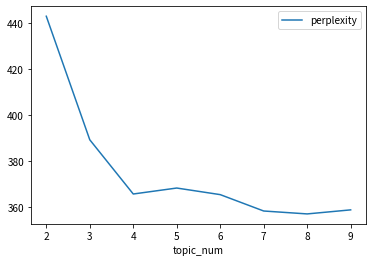

In [124]:
result.plot.line(x='topic_num', y='perplexity')

<AxesSubplot:xlabel='topic_num'>

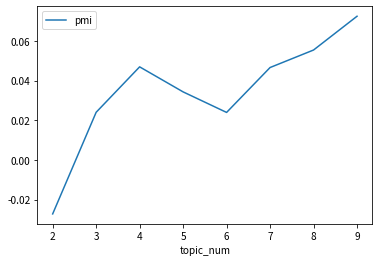

In [125]:
result.plot.line(x='topic_num', y='pmi')

就訓練結果來看，perplexity 在 4 之後都不錯，coherence 最高則是 9

##  視覺化呈現

### 產生 LDAvis 結果

以下用主題數 9 來做 LDAvis 的結果範例

In [135]:
best_model = LdaModel(
    corpus = corpus,
    num_topics = 9,
    id2word=dictionary,
    random_state = 1500,
    passes = 20 # 訓練次數
    )

2023-06-08 13:05:54,790 : INFO : using symmetric alpha at 0.1111111111111111
2023-06-08 13:05:54,790 : INFO : using symmetric eta at 0.1111111111111111
2023-06-08 13:05:54,792 : INFO : using serial LDA version on this node
2023-06-08 13:05:54,793 : INFO : running online (multi-pass) LDA training, 9 topics, 20 passes over the supplied corpus of 1500 documents, updating model once every 1500 documents, evaluating perplexity every 1500 documents, iterating 50x with a convergence threshold of 0.001000
2023-06-08 13:05:55,588 : INFO : -7.303 per-word bound, 158.0 perplexity estimate based on a held-out corpus of 1500 documents with 97195 words
2023-06-08 13:05:55,589 : INFO : PROGRESS: pass 0, at document #1500/1500
2023-06-08 13:05:56,261 : INFO : topic #7 (0.111): 0.018*"電影" + 0.011*"時間" + 0.011*"喜歡" + 0.010*"劇情" + 0.010*"看到" + 0.008*"最後" + 0.008*"知道" + 0.008*"主角" + 0.006*"出現" + 0.006*"市場"
2023-06-08 13:05:56,262 : INFO : topic #2 (0.111): 0.019*"原文" + 0.018*"時間" + 0.011*"看到" + 0.010*"台灣"

In [136]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
7      0.016924  0.160256       1        1  19.065515
4      0.114685  0.087553       2        1  17.597793
3      0.250988 -0.111788       3        1  13.886591
2     -0.255720 -0.131281       4        1  13.420322
1      0.216762 -0.025562       5        1  11.698610
5      0.202370 -0.076416       6        1   7.437692
0     -0.245270 -0.145855       7        1   6.491243
8     -0.104690  0.160053       8        1   6.105079
6     -0.196048  0.083039       9        1   4.297155, topic_info=    Term        Freq        Total Category  logprob  loglift
681   電影  810.000000   810.000000  Default  30.0000  30.0000
75    公司  750.000000   750.000000  Default  29.0000  29.0000
8     原文  769.000000   769.000000  Default  28.0000  28.0000
39    工作  358.000000   358.000000  Default  27.0000  27.0000
276  台積電  253.000000   253.000000  Default  26.0000  26.0000
..   ...         ...          ...      ...      ...      ...
275   使用   39.388347   256.966066   Topic9  -4.6638   1.2717
47    目前   54.365445   496.682270   Topic9  -4.3415   0.9350
174   相關   29.081369   207.341447   Topic9  -4.9672   1.1829
44    時間   41.913033  1576.863906   Topic9  -4.6017  -0.4804
194   機會   29.990333   262.536489   Topic9  -4.9364   0.9777

[453 rows x 6 columns], token_table=      Topic      Freq Term
term                      
61        1  0.243176   一下
61        2  0.374992   一下
61        3  0.043181   一下
61        4  0.011363   一下
61        5  0.159087   一下
...     ...       ...  ...
605       6  0.055358   麵條
553       2  0.033795   點餐
553       3  0.430882   點餐
553       5  0.464677   點餐
553       6  0.067589   點餐

[1657 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 5, 4, 3, 2, 6, 1, 9, 7])

##### 上面使用主題9來進行LDAvis得出的結果中，主題4和7完全重疊，因此決定減少一個主題數看看成果

In [137]:
best_model = LdaModel(
    corpus = corpus,
    num_topics = 8,
    id2word=dictionary,
    random_state = 1500,
    passes = 20 # 訓練次數
    )

2023-06-08 13:07:51,936 : INFO : using symmetric alpha at 0.125
2023-06-08 13:07:51,937 : INFO : using symmetric eta at 0.125
2023-06-08 13:07:51,938 : INFO : using serial LDA version on this node
2023-06-08 13:07:51,939 : INFO : running online (multi-pass) LDA training, 8 topics, 20 passes over the supplied corpus of 1500 documents, updating model once every 1500 documents, evaluating perplexity every 1500 documents, iterating 50x with a convergence threshold of 0.001000
2023-06-08 13:07:52,802 : INFO : -7.278 per-word bound, 155.2 perplexity estimate based on a held-out corpus of 1500 documents with 97195 words
2023-06-08 13:07:52,803 : INFO : PROGRESS: pass 0, at document #1500/1500
2023-06-08 13:07:53,473 : INFO : topic #4 (0.125): 0.016*"時間" + 0.012*"公司" + 0.011*"最後" + 0.009*"看到" + 0.009*"電影" + 0.008*"拉麵" + 0.007*"好吃" + 0.007*"工作" + 0.006*"知道" + 0.006*"一下"
2023-06-08 13:07:53,474 : INFO : topic #0 (0.125): 0.018*"最後" + 0.013*"原文" + 0.013*"電影" + 0.013*"公司" + 0.012*"股東" + 0.010*"看到"

In [138]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5      0.207514 -0.078626       1        1  25.060703
7      0.001549  0.199229       2        1  19.238320
4      0.105033  0.113908       3        1  15.765634
2     -0.274260 -0.080454       4        1  15.295816
6     -0.124213  0.113695       5        1   7.716875
0     -0.274780 -0.098409       6        1   6.798442
1      0.176565  0.003392       7        1   5.955900
3      0.182590 -0.172734       8        1   4.168311, topic_info=    Term        Freq        Total Category  logprob  loglift
681   電影  810.000000   810.000000  Default  30.0000  30.0000
75    公司  742.000000   742.000000  Default  29.0000  29.0000
8     原文  779.000000   779.000000  Default  28.0000  28.0000
525   飯店  336.000000   336.000000  Default  27.0000  27.0000
39    工作  350.000000   350.000000  Default  26.0000  26.0000
..   ...         ...          ...      ...      ...      ...
419   餐廳   54.329081   528.780860   Topic8  -4.3118   0.9021
44    時間   63.988905  1577.536620   Topic8  -4.1481  -0.0273
533   圖文   32.562395   274.078277   Topic8  -4.8237   1.0474
534   地址   33.469573   407.021959   Topic8  -4.7962   0.6794
459   電話   32.494459   331.255271   Topic8  -4.8257   0.8558

[404 rows x 6 columns], token_table=      Topic      Freq Term
term                      
61        1  0.160832   一下
61        2  0.248141   一下
61        3  0.351533   一下
61        4  0.018381   一下
61        5  0.110285   一下
...     ...       ...  ...
552       7  0.449648   麵包
552       8  0.335331   麵包
605       1  0.894737   麵條
605       3  0.077323   麵條
605       8  0.022092   麵條

[1413 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 8, 5, 3, 7, 1, 2, 4])

 ##### 縮減後主題4和6依然重複性很高，分別查看其他各個主題的內容，發現主題1,7,8的內容相近，都和美食、餐廳推薦相關，再參考前面計算出的perplexity，因此決定縮小主題數至4，並提高訓練次數

In [145]:
best_model = LdaModel(
    corpus = corpus,
    num_topics = 4,
    id2word=dictionary,
    random_state = 1500,
    passes = 25 # 訓練次數
    )

2023-06-08 13:19:27,950 : INFO : using symmetric alpha at 0.25
2023-06-08 13:19:27,951 : INFO : using symmetric eta at 0.25
2023-06-08 13:19:27,952 : INFO : using serial LDA version on this node
2023-06-08 13:19:27,953 : INFO : running online (multi-pass) LDA training, 4 topics, 25 passes over the supplied corpus of 1500 documents, updating model once every 1500 documents, evaluating perplexity every 1500 documents, iterating 50x with a convergence threshold of 0.001000
2023-06-08 13:19:28,837 : INFO : -7.138 per-word bound, 140.8 perplexity estimate based on a held-out corpus of 1500 documents with 97195 words
2023-06-08 13:19:28,838 : INFO : PROGRESS: pass 0, at document #1500/1500
2023-06-08 13:19:29,528 : INFO : topic #0 (0.250): 0.016*"最後" + 0.014*"電影" + 0.010*"公司" + 0.009*"看到" + 0.008*"原文" + 0.008*"時間" + 0.008*"知道" + 0.008*"股東" + 0.006*"市場" + 0.006*"角色"
2023-06-08 13:19:29,529 : INFO : topic #1 (0.250): 0.019*"時間" + 0.012*"公司" + 0.007*"喜歡" + 0.007*"感覺" + 0.006*"知道" + 0.006*"口感" +

In [146]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.189717 -0.131116       1        1  33.380564
2      0.285999 -0.070033       2        1  24.228816
1     -0.072842  0.002642       3        1  22.069046
0     -0.023440  0.198507       4        1  20.321575, topic_info=    Term        Freq       Total Category  logprob  loglift
681   電影  812.000000  812.000000  Default  30.0000  30.0000
8     原文  773.000000  773.000000  Default  29.0000  29.0000
75    公司  745.000000  745.000000  Default  28.0000  28.0000
728   劇情  319.000000  319.000000  Default  27.0000  27.0000
532   口感  465.000000  465.000000  Default  26.0000  26.0000
..   ...         ...         ...      ...      ...      ...
116   一直  137.393770  312.474083   Topic4  -4.9681   0.7718
60    資訊  115.035925  217.332568   Topic4  -5.1457   0.9573
15    現在  121.743696  332.364250   Topic4  -5.0891   0.5892
61    一下  112.442441  438.647110   Topic4  -5.1685   0.2322
111   問題  108.128375  272.882091   Topic4  -5.2077   0.6678

[238 rows x 6 columns], token_table=      Topic      Freq Term
term                      
61        1  0.234813   一下
61        2  0.025077   一下
61        3  0.485584   一下
61        4  0.255331   一下
599       1  0.994381   一口
...     ...       ...  ...
582       3  0.005147   香氣
605       1  0.981673   麵條
605       3  0.011030   麵條
553       1  0.986715   點餐
553       3  0.008506   點餐

[457 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 3, 2, 1])

##### 這次的分類相較前幾次就比較好，可以清楚分辨出各主題的內容：
- 主題一：餐廳/食物
- 主題二：全球產業/股市
- 主題三：日本旅遊
- 主題四：電影

lambda 的意義: <https://nlp.stanford.edu/events/illvi2014/papers/sievert-illvi2014.pdf>

In [147]:
pyLDAvis.save_html(p, "lda_zh.html")

## GuidedLDA

In [148]:
import guidedlda

In [149]:
vocab = tuple(dictionary.token2id.keys())
vocab[:10]

('一年', '三個', '不錯', '主管', '今年', '兩個', '分享', '印象', '原文', '參考')

In [150]:
word2id = dictionary.token2id

In [171]:
seed_topic_list = [
    [
        '公司', '工作', '工程師', '面試', '薪資', '主管', '前輩', '薪水', '加班', '年薪', '職位', 
        '部門', '科技', '大學', '單位', '發展',  '管理', '客戶', '產業',
        '現職', '調薪', '電子', '老闆', '轉職', '製程', '系統', '出差', '同事', '系統廠', '企業',
        '新竹', '背景', '加班費', '員工', '下班', '離職', '績效', '月薪', '通勤', '人資', '年終', '福利',
        '裁員', '年資', '辦公室', '發展性', '軟體', '台積電', '技術', '跳槽',
    ],
    [
        '餐廳', '口感', '好吃', '吃起來', '營業', '消費', '味道', '用餐', '口味', '店家', '搭配', '價位', '餐點', 
        '菜單', '甜點', '香氣', '咖啡', '菜色', '店內', '價格', '份量', '美味', '料理', '刷卡', '套餐', '吃到飽', 
        '牛排', '包廂', '環境', '美食', '招牌', '蛋糕', '品項', '海鮮', '雞肉', '麵包', '調味', '豆腐', '小菜', '客人', 
        '沙拉', '飲料', '湯頭', '食材', '火鍋', '空間', '醬汁', '點餐', '新鮮', '服務', '豬肉', '風味', '座位', '公休', 
        '濃湯', '豐富', '蔬菜', '飲品', '濃郁', '雞腿', '酥脆', '老闆', '清爽', '蛤蜊', '軟嫩', '便當', '滋味', '吃完', 
        '奶油', '饅頭', '吃過', '檸檬', '外帶', '巧克力', '冰淇淋', '肉質', '起司', '配料', '泰式', '配菜', '特色', '外皮', 
        '排隊', '炸雞', '傳統', '原味', '燉飯', '早餐',
    ],
    [
        '市場', '發布', '美國', '億元', '投資', '台積電', '股東', '營收', '銀行', '台灣', '中國', '經濟', '台股', '半導體', 
        '股利', '持續', '預期', '股價', '指數', '影響', '全球', '成長', '產業', '獲利', '晶片', '現金', '股票', '億美', '美元', 
        '政策', '基金', '升息', '外資', '通膨', '董事長', '金融', '第季', '表現', '企業', '大陸', '政府', '奈米', '業者', '新光金', 
        '董事', '增加', '價格', '投資人', '上市', '景氣', '發展', '下半年', '生產', '營運', '資本', '每股', '預估', '股市', '庫存', 
        '蘋果', '上漲', '資金', '股東會', '國際', '衰退', '調整', '成本', '金管會', '泰山', '交易', '盈餘', '配息', '公布', '董事會', 
        '製程', '數據', '聯準會', '法人', '風險', '輝達', '業務', '利率', '美股', '長榮', '漲幅', '股息', '虧損',
    ],
    [
        '飯店', '日本', '車站', '神社', '造訪', '行程', '東京', '京都', '拉麵', '機場', '排隊', '北海道', '推薦', '札幌', '景點',
        '抵達', '巴士', '台灣', '櫻花', '大阪', '住宿', '日幣', '博多', '抹茶', '行李', '溫泉', '旅館', '體驗', '預約', '纜車', 
        '仙台', '入住', '烏龍麵', '入境', '福岡', '醬油', '壽司', '函館', '牛肉', '鰻魚', '飛機', '日文', '神宮', '旅行', 
        '燒肉', '富士山', '遊客', '電車', '球場', '富山', '日式', '海鮮', '牛舌', '叉燒', '名古屋', '旅伴', '吃到飽', '醬汁', '熊本', 
        '冰淇淋', '羽田', '新幹線', '定食',
    ],
    [
        '電影', '劇情', '角色', '這部', '主角', '故事', '雷文', '觀眾', '防雷', '畫面', '作品', '導演', '動畫', '漫畫', '一部',
        '主文', '鈴芽', '蟻人', '日本', '本片', '櫻木', '比賽', '新海', '好看', '系列', '節奏', '人物', '漫威',
        '三井', '電影院', '感動', '上映', '期待', '結局', '反派', '設定', '場景', '內容', '呈現', '名字', '情感', '電影版', 
        '高手', '劇場版', '整部', '灌籃', '有趣', '演員', '經典', '預告', '星際', '橋段', '那段', '真實', '音樂', '細節', '觀影', 
        '印象', '心得', '推薦', '特效', '風格', '台詞', '這片', '開頭', '背景', '動作', '完整', '靈魂', '異攻隊', '元素', '場面', 
        '原作', '票房', '結尾', '觀賞', '片段', '影片', '美國', '流川', '冒險', '井上', '事件', '兄弟', '改編', '戲院', '感受到', 
        '關鍵', '笑點', '想像', '感受', '評價', '類似', '製作', '進場', '對話', '英雄', '熱血', '劇本', '後續', '彩蛋'
    ]
]

In [172]:
seed_topics = {}
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        if word in word2id:
            seed_topics[word2id[word]] = t_id

In [173]:
X = corpus2dense(corpus, len(dictionary), len(corpus)).T.astype(np.int64)

In [174]:
model = guidedlda.GuidedLDA(n_topics=5, n_iter=100, random_state=7, refresh=20)
model.fit(X, seed_topics=seed_topics, seed_confidence=1)

2023-06-08 13:30:36,973 : INFO : n_documents: 1500
2023-06-08 13:30:36,974 : INFO : vocab_size: 734
2023-06-08 13:30:36,974 : INFO : n_words: 97195
2023-06-08 13:30:36,975 : INFO : n_topics: 5
2023-06-08 13:30:36,975 : INFO : n_iter: 100
2023-06-08 13:30:36,977 : WARNING : all zero row in document-term matrix found
2023-06-08 13:30:37,178 : INFO : <0> log likelihood: -743673
2023-06-08 13:30:37,285 : INFO : <20> log likelihood: -591043
2023-06-08 13:30:37,389 : INFO : <40> log likelihood: -588173
2023-06-08 13:30:37,533 : INFO : <60> log likelihood: -587528
2023-06-08 13:30:37,642 : INFO : <80> log likelihood: -587434
2023-06-08 13:30:37,750 : INFO : <99> log likelihood: -587125


In [175]:
n_top_words = 10
topic_word = model.topic_word_

for i, topic_dist in enumerate(topic_word):
    topic_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    print("Topic {}: {}".format(i, " ".join(topic_words)))
    

doc_topic = model.doc_topic_
term_freq = tuple(dictionary.cfs.values())
doc_len = [sum(v for k, v in doc) for doc in corpus]

## LDAvis
pyLDAvis.enable_notebook()
p = pyLDAvis.prepare(topic_word, doc_topic, doc_len, vocab = vocab, term_frequency = term_freq)
p

Topic 0: 公司 工作 目前 小弟 內容 工程師 薪資 問題 主管 面試
Topic 1: 時間 餐廳 口感 好吃 地址 營業 吃起來 口味 味道 店家
Topic 2: 原文 市場 今年 公司 記者 表示 時間 去年 美國 發布
Topic 3: 飯店 日本 時間 看到 車站 神社 行程 東京 造訪 京都
Topic 4: 電影 最後 劇情 知道 角色 看到 這部 喜歡 故事 主角


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.213050  0.156493       1        1  32.259770
2      0.275520  0.137072       2        1  21.708245
4     -0.044059 -0.124733       3        1  20.373839
3     -0.147947 -0.043062       4        1  17.661175
0      0.129536 -0.125771       5        1   7.996970, topic_info=    Term        Freq        Total Category  logprob  loglift
681   電影  816.000000   816.000000  Default  30.0000  30.0000
75    公司  750.000000   750.000000  Default  29.0000  29.0000
8     原文  777.000000   777.000000  Default  28.0000  28.0000
39    工作  359.000000   359.000000  Default  27.0000  27.0000
525   飯店  348.000000   348.000000  Default  26.0000  26.0000
..   ...         ...          ...      ...      ...      ...
6     分享   68.959564   219.950625   Topic5  -4.7248   1.3662
126   產品   66.961026   209.953493   Topic5  -4.7543   1.3833
40    希望   65.961757   207.948293   Topic5  -4.7693   1.3779
44    時間   69.958833  1585.501528   Topic5  -4.7105  -0.5946
34    台灣   63.963218   525.851260   Topic5  -4.8001   0.4194

[273 rows x 6 columns], token_table=      Topic      Freq Term
term                      
61        1  0.203674   一下
61        2  0.013578   一下
61        3  0.253461   一下
61        4  0.416401   一下
61        5  0.113152   一下
...     ...       ...  ...
419       3  0.005662   餐廳
419       4  0.020760   餐廳
550       1  1.000143   餐點
582       1  1.000076   香氣
553       1  0.999906   點餐

[538 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 5, 4, 1])

## 主題分佈的應用，搭配其他文章資訊

In [180]:
# 取得每條新聞的主題分佈
topics_doc = best_model.get_document_topics(corpus)

In [181]:
topics_doc[100]

[(0, 0.5557961), (1, 0.012661823), (2, 0.41952342), (3, 0.012018705)]

In [182]:
m_theta = corpus2csc(topics_doc).T.toarray()
m_theta

array([[0.        , 0.8565051 , 0.12435794, 0.        ],
       [0.35562104, 0.03059383, 0.58534628, 0.0284389 ],
       [0.        , 0.4049671 , 0.58248228, 0.        ],
       ...,
       [0.98438972, 0.        , 0.        , 0.        ],
       [0.99259955, 0.        , 0.        , 0.        ],
       [0.98796713, 0.        , 0.        , 0.        ]])

In [183]:
udn['topic_label'] = m_theta.argmax(axis=1) + 1

In [184]:
udn['topic_label'].value_counts()

topic_label
2    449
4    377
3    339
1    335
Name: count, dtype: int64

In [185]:
udn.head()

,content,artUrl,artCatagory,artDate,words,topic_label
0,轉貼醋院的薪水分享節錄部分科技業爆發前進去醋院第一年未滿一年本薪餐補年中年終調薪考績第二年滿...,https://www.ptt.cc/bbs/Tech_Job/M.1675310634.A...,Tech_Job,2023-02-02 12:03:52,"[轉貼, 醋院, 薪水, 分享, 節錄, 科技業, 爆發, 前進, 醋院, 第一年, 未滿,...",2
1,嗨囉我就機械仔雖然修完但出社會後依然面對現實最近拿到的都是半導體方面的設備機構該選哪個勒還是轉生,https://www.ptt.cc/bbs/Tech_Job/M.1683208121.A...,Tech_Job,2023-05-04 21:48:39,"[機械, 修完, 但出, 社會, 依然, 面對, 現實, 最近, 拿到, 半導體, 方面, ...",3
2,各位新年好這裡是國立政治大學心理學研究所系工商心理學組的碩士班研究生目前正在進行碩士論文的研...,https://www.ptt.cc/bbs/Tech_Job/M.1674480733.A...,Tech_Job,2023-01-23 21:32:11,"[新年, 國立, 政治, 大學, 心理學, 研究所, 工商, 心理學, 碩士班, 研究生, ...",3
3,各位年薪三百的大大好想請問有沒有聽過衡陞科技的大大在站上或估狗爬文都找不太到資訊想問問裡面風...,https://www.ptt.cc/bbs/Tech_Job/M.1676493334.A...,Tech_Job,2023-02-16 04:35:32,"[年薪, 三百, 請問, 有沒有, 過衡, 科技, 站上, 估狗, 爬文, 不太到, 資訊,...",2
4,最近來一位姑且稱長官專案成員中跟能力接近但不得長官心因為他之前開會直接嗆長官的話有大奶優勢加...,https://www.ptt.cc/bbs/Tech_Job/M.1682945779.A...,Tech_Job,2023-05-01 20:56:14,"[最近, 一位, 長官, 專案, 成員, 能力, 接近, 長官, 開會, 直接, 長官, 大...",1


In [195]:
udn['artDate'] = pd.to_datetime(udn['artDate'])


In [196]:
udn['artDate'].dt.date

0       2023-02-02
1       2023-05-04
2       2023-01-23
3       2023-02-16
4       2023-05-01
           ...    
1495    2023-02-18
1496    2023-01-14
1497    2023-05-25
1498    2023-04-16
1499    2023-01-30
Name: artDate, Length: 1500, dtype: object

In [197]:
udn.groupby(udn['artDate'].dt.date)['topic_label'].value_counts(normalize=True)

artDate     topic_label
2023-01-01  1              1.000000
2023-01-02  1              0.666667
            2              0.333333
2023-01-03  4              0.333333
            2              0.333333
                             ...   
2023-05-30  1              0.071429
2023-05-31  3              0.500000
            2              0.312500
            4              0.125000
            1              0.062500
Name: proportion, Length: 484, dtype: float64

In [198]:
date_topic = udn.groupby(udn['artDate'].dt.date)['topic_label'].value_counts(normalize=True).unstack()
date_topic.head()

topic_label,1,2,3,4
artDate,,,,
2023-01-01,1.000000,NaN,NaN,NaN
2023-01-02,0.666667,0.333333,NaN,NaN
2023-01-03,0.333333,0.333333,NaN,0.333333
2023-01-04,0.333333,0.500000,NaN,0.166667
2023-01-05,NaN,0.833333,NaN,0.166667


<AxesSubplot:xlabel='artDate'>

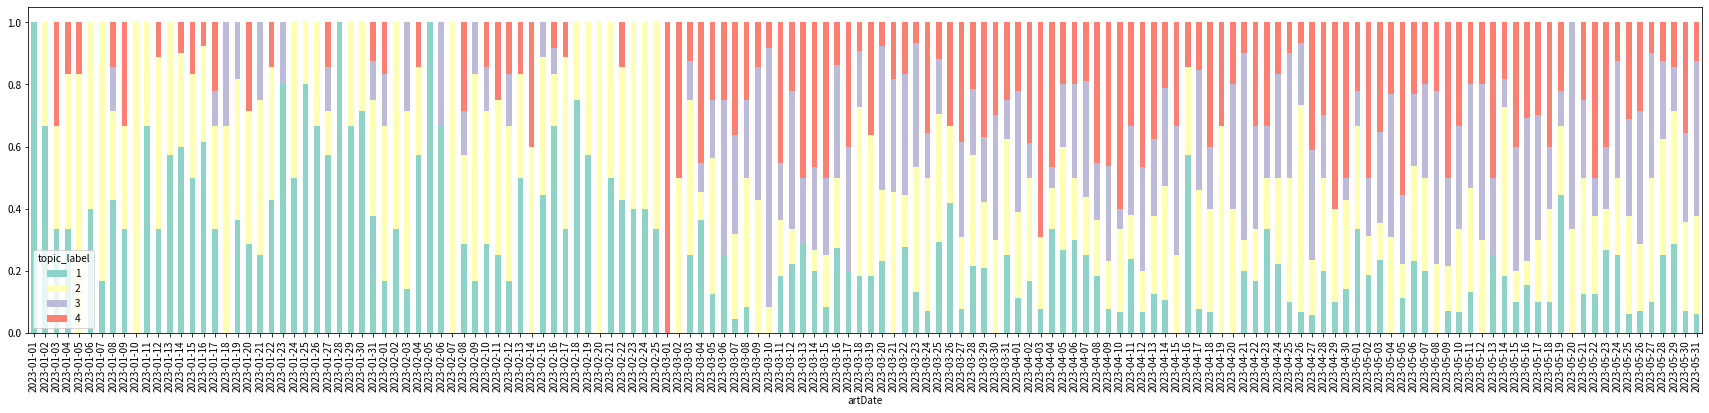

In [200]:
fig, ax = plt.subplots(figsize=(30, 6))
date_topic.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)

透過搭配文章的資訊（例如日期等），可以讓主題模型的結果做出更多的分析應用
根據前面的LDA：
- 主題一：餐廳/食物
- 主題二：全球產業/股市
- 主題三：日本旅遊
- 主題四：電影

從上圖可以發現一個趨勢，有關日本旅遊、電影的這兩個主題的貼文比例，在3月後大幅增加，推斷可能是因為疫情趨緩，政府防疫政策放寬，大家漸漸開始外出。